In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df = pd.read_csv("../Dataset/LLMcrypto/train.csv")

print("HEAD:")
print(df.head())

print("\nINFO:")
print(df.info())

print("\nSUMMARY:")
print(df.describe(include='all'))


HEAD:
   Unnamed: 0                                           question  \
0           0  What significant challenges does the rapid exp...   
1           1  How does the proposed framework address the in...   
2           2  What are the primary benefits of using blockch...   
3           3  Why are traditional blockchain-based solutions...   
4           4  How does the proposed framework ensure data pr...   

                                              answer  \
0  Balancing scalability and security, computatio...   
1  By employing edge aggregating servers and Ethe...   
2  Data integrity, device authentication, and pro...   
3  Due to scalability, cost issues, and computati...   
4  Through the use of Zero-Knowledge Proofs (ZKPs...   

                                                text  
0  ###Human:\nAnswer this question in the context...  
1  ###Human:\nAnswer this question in the context...  
2  ###Human:\nAnswer this question in the context...  
3  ###Human:\nAnswer this qu


MISSING VALUES:
Unnamed: 0    0
question      0
answer        0
text          0
dtype: int64


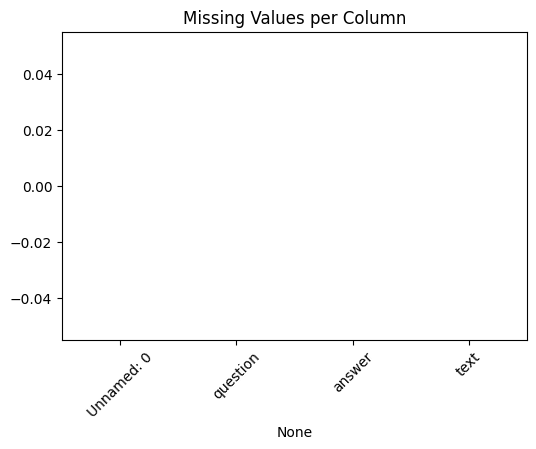

In [3]:
print("\nMISSING VALUES:")
print(df.isnull().sum())

plt.figure(figsize=(6,4))
sns.barplot(x=df.isnull().sum().index, y=df.isnull().sum().values)
plt.xticks(rotation=45)
plt.title("Missing Values per Column")
plt.show()


In [4]:
df["question_len"] = df["question"].astype(str).str.len()
df["answer_len"] = df["answer"].astype(str).str.len()

print(df[["question_len", "answer_len"]].describe())


       question_len  answer_len
count    804.000000  804.000000
mean      75.299751  103.195274
std       17.556625   40.473695
min       30.000000    5.000000
25%       64.000000   80.000000
50%       75.000000  103.000000
75%       86.000000  129.000000
max      141.000000  487.000000


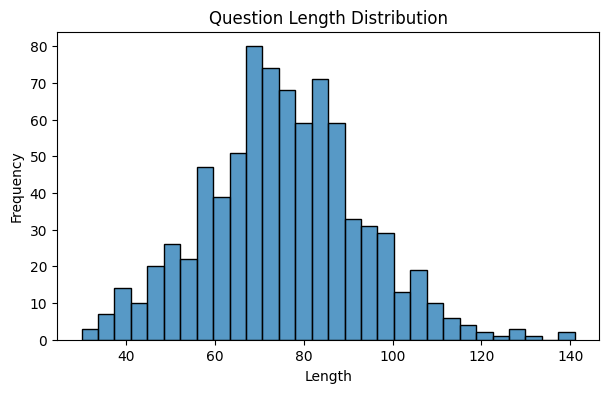

In [5]:
# Distribution of Question Lengths
plt.figure(figsize=(7,4))
sns.histplot(df["question_len"], bins=30)
plt.title("Question Length Distribution")
plt.xlabel("Length")
plt.ylabel("Frequency")
plt.show()


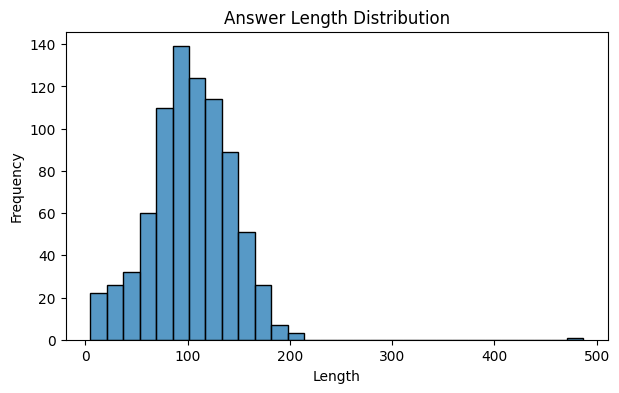

In [6]:
# Distribution of Answer Lengths
plt.figure(figsize=(7,4))
sns.histplot(df["answer_len"], bins=30)
plt.title("Answer Length Distribution")
plt.xlabel("Length")
plt.ylabel("Frequency")
plt.show()


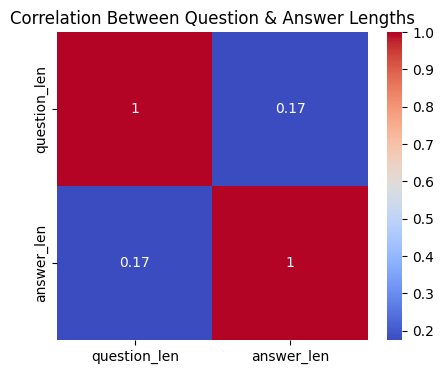

In [7]:
# Correlation Heatmap
plt.figure(figsize=(5,4))
sns.heatmap(df[["question_len", "answer_len"]].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Between Question & Answer Lengths")
plt.show()


In [8]:
# Word Count Features
df["question_words"] = df["question"].astype(str).apply(lambda x: len(x.split()))
df["answer_words"] = df["answer"].astype(str).apply(lambda x: len(x.split()))

print(df[["question_words", "answer_words"]].describe())


       question_words  answer_words
count      804.000000    804.000000
mean        11.324627     13.771144
std          2.516761      5.496732
min          5.000000      1.000000
25%         10.000000     11.000000
50%         11.000000     14.000000
75%         13.000000     17.000000
max         21.000000     69.000000


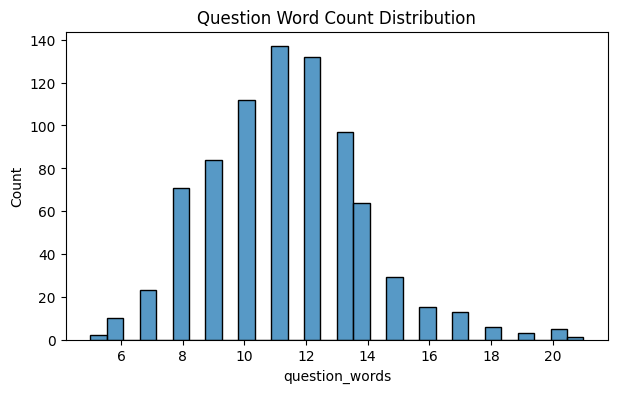

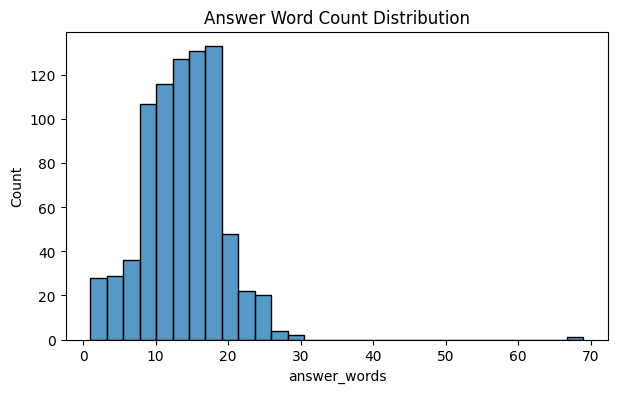

In [9]:
# Word Count Distributions
plt.figure(figsize=(7,4))
sns.histplot(df["question_words"], bins=30)
plt.title("Question Word Count Distribution")
plt.show()

plt.figure(figsize=(7,4))
sns.histplot(df["answer_words"], bins=30)
plt.title("Answer Word Count Distribution")
plt.show()


In [10]:
# View Example Text Entry
print("Sample Text Entry:\n")
print(df["text"].iloc[0])


Sample Text Entry:

###Human:
Answer this question in the context of cryptocurrency, stock markets and blockchain.
What significant challenges does the rapid expansion of IoT introduce in data authentication?

###Assistant:
Balancing scalability and security, computational and storage bottlenecks.


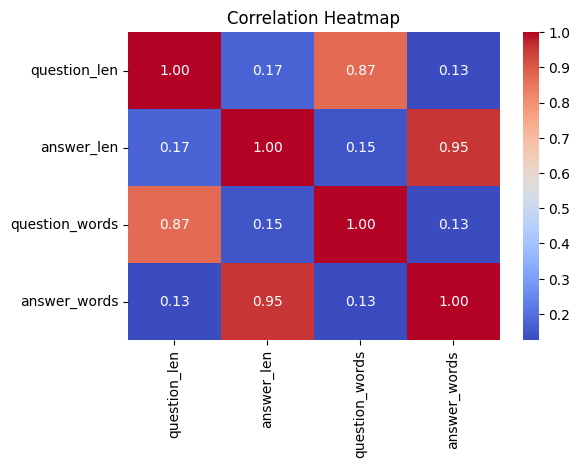

In [12]:
# Correlation Heatmap
plt.figure(figsize=(6,4))
sns.heatmap(df[["question_len", "answer_len", "question_words", "answer_words"]].corr(),annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

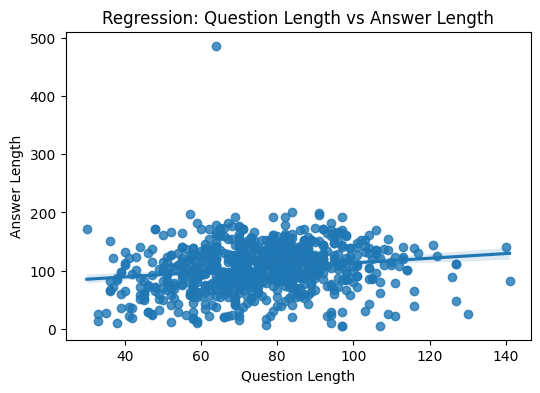

In [13]:
# Regression Plot (Linear Regression Between Two Variables)
plt.figure(figsize=(6,4))
sns.regplot(x=df["question_len"], y=df["answer_len"])
plt.title("Regression: Question Length vs Answer Length")
plt.xlabel("Question Length")
plt.ylabel("Answer Length")
plt.show()


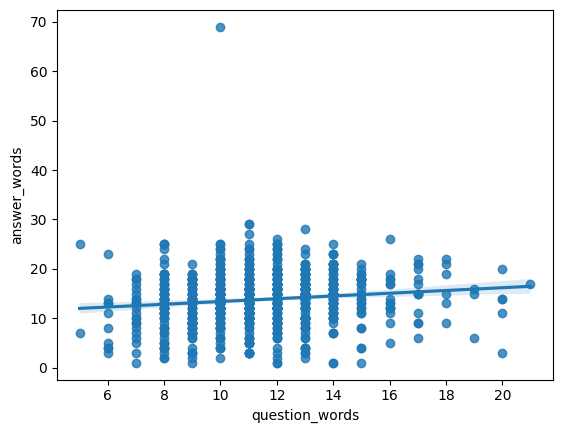

In [ ]:
# Word count
sns.regplot(x=df["question_words"], y=df["answer_words"])
plt.show()
